In [138]:
import torch
import torch.nn.functional as F
import imageio
import numpy as np

In [139]:
import os
import torch
import sys
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface import WaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

Dataset = LoadDataset()
Dataset.set_iamge(0)

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


In [140]:
def get_rays(
    width: int = 640,
    height: int = 480,
    K: torch.Tensor = None, # (3, 3)
    camtoworld: torch.Tensor = None, # (4, 4)
): # -> torch.Tensor: (width, height, 3) 
    assert K.shape == (3, 3), "K should be of shape (3, 3)"
    assert camtoworld.shape == (4, 4), "camtoworld should be of shape (4, 4)"
    
    print(f'K:\n {K}')
    print(f'camtoworld:\n {camtoworld}')
    print(f'worldtocam:\n {torch.linalg.inv(camtoworld)}')
    
    device = K.device
    o = camtoworld[:3, 3]
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    # (H, W) indexing
    v, u = torch.meshgrid(
        torch.arange(0, height, device=device),
        torch.arange(0, width, device=device),
        indexing='ij'
    )

    d = torch.stack([
        (u - cx) / fx,
        -(v - cy) / fy,
        torch.ones_like(u) 
    ], dim=-1)  # (H, W, 3)

    # Rotate ray directions to world coordinates
    d = torch.einsum('ij,hwj->hwi', camtoworld[:3, :3], d)
    d = d / torch.norm(d, dim=-1, keepdim=True)

    # Expand camera origin
    o = o.view(1, 1, 3).expand(height, width, 3)

    return o, d 



o, rays = get_rays(
    width=width,
    height=height,
    K=K[0],
    camtoworld=camtoworld[0]
)

print(rays[width//2, height//2])

K:
 tensor([[380.8394,   0.0000, 400.0000],
        [  0.0000, 380.8394, 400.0000],
        [  0.0000,   0.0000,   1.0000]], device='cuda:0')
camtoworld:
 tensor([[  1.0000,  -0.0000,  -0.0000, -11.2033],
        [  0.0000,  -1.0000,  -0.0000, -11.2033],
        [  0.0000,  -0.0000,  -1.0000,  20.0000],
        [  0.0000,   0.0000,   0.0000,   1.0000]], device='cuda:0')
worldtocam:
 tensor([[  1.0000,   0.0000,   0.0000,  11.2033],
        [  0.0000,  -1.0000,  -0.0000, -11.2033],
        [  0.0000,   0.0000,  -1.0000,  20.0000],
        [  0.0000,   0.0000,   0.0000,   1.0000]], device='cuda:0')
tensor([ 0.,  0., -1.], device='cuda:0')


In [141]:
# plot the rays
plt.figure(figsize=(10, 10))

# Create a water surface

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [142]:
# FOV
edge_ray_1 = rays[0,0,:]
edge_ray_2 = rays[-1,-1,:]

def get_fov(edge_ray_1, edge_ray_2):
    """
    Calculate the field of view (FOV) based on two edge rays.
    """
    # Normalize the rays
    edge_ray_1 = edge_ray_1 / torch.norm(edge_ray_1)
    edge_ray_2 = edge_ray_2 / torch.norm(edge_ray_2)

    # Calculate the angle between the two rays
    cos_theta = torch.dot(edge_ray_1, edge_ray_2)
    angle_rad = torch.acos(cos_theta)

    # Convert to degrees
    angle_deg = torch.rad2deg(angle_rad)

    return angle_deg.item()
fov = get_fov(edge_ray_1, edge_ray_2)
fov

112.03385925292969

In [143]:
# env_np = imageio.imread("qwantani_dusk_2_1k.exr", format="EXR")
env_np = imageio.imread("rainforest_trail_2k.exr", format="EXR")
print("env_np.shape:", env_np.shape)

env = torch.from_numpy(env_np[:,:,:]).permute(2,0,1).unsqueeze(0).cuda()
print("env.shape:", env.shape)

env_np.shape: (1024, 2048, 4)
env.shape: torch.Size([1, 4, 1024, 2048])


/tmp/ipykernel_2120774/171319986.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  env_np = imageio.imread("rainforest_trail_2k.exr", format="EXR")


In [144]:
x, y, z = rays.unbind(dim=-1)
phi = torch.atan2(y, x)                           # [-pi, pi] # longitude
theta = torch.acos(torch.clamp(z, -1,1))          # [0, pi] # latitude
u = phi / (2*torch.pi) + 0.5                      # [0, 1]
u = u % 1.0                                       # [0, 1]
v = theta / torch.pi                              # [0, 1]
grid = torch.stack([u*2-1, 2*v-1], dim=-1)        # [−1,1]^2

N = grid.shape[0] * grid.shape[1]
grid = grid.view(1, N, 1, 2)
sampled = F.grid_sample(env, grid, align_corners=True, mode="bilinear")
colors = sampled.view(4, N).permute(1,0) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00016313716..15.414776].


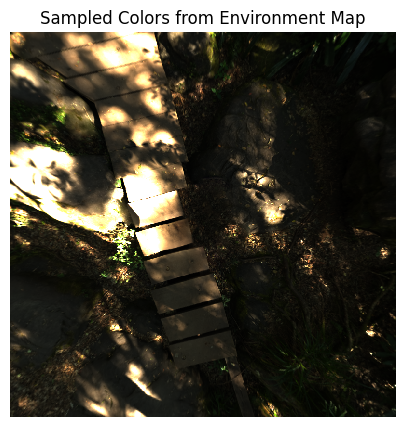

In [145]:
# show colors
colors_np = colors.cpu().numpy().reshape(height, width, 4)
plt.figure(figsize=(10, 5))
plt.imshow(colors_np)
plt.axis('off')
plt.title('Sampled Colors from Environment Map')
plt.show()

In [146]:
WS = WaterSurface(
    means=means,
    scales=scales,
    quats=quats,
    opacities=opacities,
    device=device,
    
    camtoworld=camtoworld[image_id],
    K=K[image_id],
    width=width,
    height=height,
)

rays_WS = WS.calc_ray_of_each_pixel()
WS.load_environment_map(envmap_path="rainforest_trail_2k.exr")
env_colors = WS.get_colors_from_envmap(rays_WS)
env_colors.shape

theta torch.Size([800, 800])


torch.Size([800, 800, 4])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00016313716..15.414776].


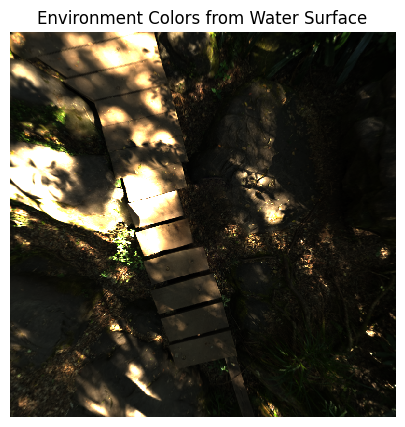

In [147]:
# show
env_colors_np = env_colors.cpu().numpy().reshape(height, width, 4)
plt.figure(figsize=(10, 5))
plt.imshow(env_colors_np)
plt.axis('off')
plt.title('Environment Colors from Water Surface')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..154.22128].


theta torch.Size([800, 800])


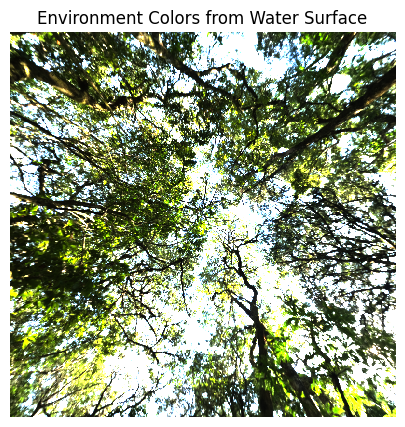

In [148]:
# refrected rays and get env map colors
reflected_rays = WS.calc_refrected_ray()
refrected_env_colors = WS.get_colors_from_envmap(reflected_rays)

refrected_env_colors_np = refrected_env_colors.cpu().numpy()
plt.figure(figsize=(10, 5))
plt.imshow(refrected_env_colors_np)
plt.axis('off')
plt.title('Environment Colors from Water Surface')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008895174..184.67679].


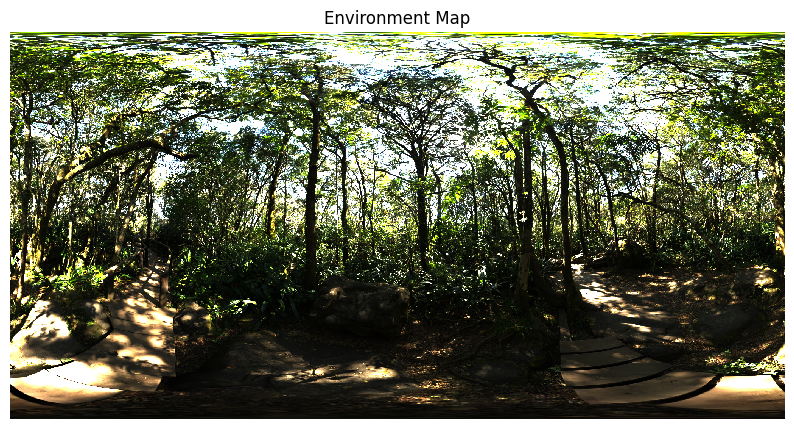

In [152]:
# show env map
plt.figure(figsize=(10, 10))
plt.imshow(env_np)
plt.axis('off')
plt.title('Environment Map')
plt.show()
